# Combining TIme-Reverse (TRV) and Time-Forward (TFWD) Simulations

In this Tutorial, we will be combining the results produced from both time-forward and time-reverse simulations in the past two tutorials. 

First we will write some basic functions to extract the field datasets.

In [2]:
# Importing various Python libraries and MeepSAT modules
import sys
import os
import site
from pathlib import Path
import meep as mp
import numpy as np
import h5py
import matplotlib.pyplot as plt
import time
import json
import math

# Importing the MEEPSAT librarires
import meepsat.simulator as sim
import meepsat.meep_geometry as comp_meep
import meepsat.permittivity_components as comp_eps
import meepsat.stepfunctions as stepfunctions
import meepsat.json_to_script as json_to_script
import meepsat.field_analysis as mpsat_analysis
import meepsat.helpers as mpsat_helpers

Using MPI version 4.1, 1 processes


In [3]:
def load_fields(basepath, filename):
    """Load a field stored in an .npz file."""
    filepath = os.path.join(basepath, filename)
    return np.load(filepath)


def load_simulation_data(json_data, forebaffle_configs, savepath_dir):
    """
    Analyze all forebaffle configurations.

    Parameters
    ----------
    data : dict
        Simulation JSON input data.
    forebaffle_configs : list
        List of forebaffle configurations.
    savepath_dir : str
        Directory containing the simulation outputs.

    Returns
    -------
    list
        List of dictionaries containing the computed fields for each configuration.
    """
    results = []

    for i, config in enumerate(forebaffle_configs):
        print(f"\n{'=' * 50}")
        print(f"Analysing simulation {i + 1}/{len(forebaffle_configs)}", "Config:", config)
        print(f"{'=' * 50}\n")

        # Load the simulation data for the current configuration
        with open(json_data, 'r') as f:
            sim_data = json.load(f)
        sim_data["simulation"]["name"] += f"_config_{i}"

        savepath = os.path.join(savepath_dir, f"config_{i}")

        # Load field data
        e_data = load_fields(savepath, "efield_timeavg.npz")
        h_data = load_fields(savepath, "hfield_timeavg.npz")
        xyzw_data = load_fields(savepath, "xyzw.npz")

        print("E-field data keys:", e_data.files)
        print("H-field data keys:", h_data.files)
        print("XYZW data keys:", xyzw_data.files)

        # TE components
        ez = e_data["ez_real"] + 1j * e_data["ez_imag"]
        hx = h_data["hx_real"] + 1j * h_data["hx_imag"]
        hy = h_data["hy_real"] + 1j * h_data["hy_imag"]

        # Poynting vector
        sx = -ez * np.conj(hy)
        sy = ez * np.conj(hx)

        sx_mag = np.abs(sx)
        sy_mag = np.abs(sy)
        s_total = np.sqrt(sx_mag**2 + sy_mag**2)
        s_total_db = 10 * np.log10(s_total / np.max(s_total) + 1e-20)

        # E-field power
        ez_power = np.abs(ez) ** 2
        ez_power_db = 10 * np.log10(ez_power / np.max(ez_power) + 1e-20)

        results.append({
            "config": config,
            "sim_data": sim_data,
            "xyzw": xyzw_data,
            "ez": ez,
            "hx": hx,
            "hy": hy,
            "sx": sx,
            "sy": sy,
            "s_total": s_total,
            "s_total_db": s_total_db,
            "ez_power": ez_power,
            "ez_power_db": ez_power_db,
        })

    return results



In [4]:
# Some universal constants
c_mm_s = 299792458.0 * 1000.0  # Speed of light in mm/s (m/s -> mm/s)
# Frequency of the simulation
freq = 150.0  # Frequency in GHz
a = 1  # 1 meep unit = 1 mm  
wvl = c_mm_s / (freq * 1e9)  # Wavelength in mm
freq_meep = 1.0 / (wvl * a)
print("freq (meep units):", freq_meep)
freq = freq_meep

# Savepath directories
trv_savepath_dir = f'auxilary_data/02_simple_single_lens_AddedComplexities_b/TRV/output_files/{freq}GHz'
tfwd_savepath_dir = f'auxilary_data/02_simple_single_lens_AddedComplexities_b/TFWD/output_files/{freq}GHz'

# JSON input data directories
trv_json_data_dir = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TRV/simple_single_lens_AddedComplexities_TRV_b.json'
tfwd_json_data_dir = 'auxilary_data/02_simple_single_lens_AddedComplexities_b/TFWD/simple_single_lens_AddedComplexities_TFWD_b.json'

# Define multiple forebaffle configurations
forebaffle_configs = [
    # Spline config_0
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 2, "forebaffle_amplitude": 2, "forebaffle_spline_smoothing": 1},
    # Curved config_1
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 0.4, "forebaffle_amplitude": 5, "forebaffle_spline_smoothing": 1},
    # Linear config_2
    {"forebaffle_scaling_factor": 3, "forebaffle_spline_degree": 3, "forebaffle_num_periods": 1, "forebaffle_amplitude": 0, "forebaffle_spline_smoothing": 1},
]

# Load and analyze TRV simulation data
trv_results = load_simulation_data(trv_json_data_dir, forebaffle_configs, trv_savepath_dir)
# Load and analyze TFWD simulation data
tfwd_results = load_simulation_data(tfwd_json_data_dir, forebaffle_configs, tfwd_savepath_dir)

freq (meep units): 0.5003461427972281

Analysing simulation 1/3 Config: {'forebaffle_scaling_factor': 3, 'forebaffle_spline_degree': 3, 'forebaffle_num_periods': 2, 'forebaffle_amplitude': 2, 'forebaffle_spline_smoothing': 1}

E-field data keys: ['ex_real', 'ex_imag', 'ey_real', 'ey_imag', 'ez_real', 'ez_imag', 'count']
H-field data keys: ['hx_real', 'hx_imag', 'hy_real', 'hy_imag', 'hz_real', 'hz_imag', 'count']
XYZW data keys: ['x_coords', 'y_coords', 'weights']

Analysing simulation 2/3 Config: {'forebaffle_scaling_factor': 3, 'forebaffle_spline_degree': 3, 'forebaffle_num_periods': 0.4, 'forebaffle_amplitude': 5, 'forebaffle_spline_smoothing': 1}

E-field data keys: ['ex_real', 'ex_imag', 'ey_real', 'ey_imag', 'ez_real', 'ez_imag', 'count']
H-field data keys: ['hx_real', 'hx_imag', 'hy_real', 'hy_imag', 'hz_real', 'hz_imag', 'count']
XYZW data keys: ['x_coords', 'y_coords', 'weights']

Analysing simulation 3/3 Config: {'forebaffle_scaling_factor': 3, 'forebaffle_spline_degree': 3, 

In [5]:
trv_results[0]['sx']

array([[ 9.8872983e-20+4.6739065e-19j,  8.1215529e-19+4.0485085e-18j,
         1.9057373e-18+1.0618372e-17j, ...,
         1.9057373e-18+1.0618372e-17j,  8.1215529e-19+4.0485085e-18j,
         9.8872983e-20+4.6739065e-19j],
       [ 3.4014954e-19+1.5957012e-18j,  2.8183534e-18+1.3832672e-17j,
         6.7446711e-18+3.6355134e-17j, ...,
         6.7446711e-18+3.6355134e-17j,  2.8183534e-18+1.3832672e-17j,
         3.4014954e-19+1.5957012e-18j],
       [ 7.9006497e-19+3.3004438e-18j,  6.6492157e-18+2.8643279e-17j,
         1.6469482e-17+7.5503796e-17j, ...,
         1.6469482e-17+7.5503796e-17j,  6.6492157e-18+2.8643279e-17j,
         7.9006497e-19+3.3004438e-18j],
       ...,
       [-1.3518249e-22-3.6784347e-23j, -1.3285140e-21-3.6317907e-22j,
        -4.4369815e-21-1.2228005e-21j, ...,
        -4.4369815e-21-1.2228005e-21j, -1.3285140e-21-3.6317907e-22j,
        -1.3518249e-22-3.6784347e-23j],
       [-1.0213468e-22-2.7404413e-23j, -1.0085801e-21-2.7167224e-22j,
        -3.3992927e-21

Now that we have the data for all the forebaffle configuration, we will move forward in combining the TFWD and TRV $\textbf{S}$-fields to identify the radiation dominated regions present in the simulation box.

We will write a function that will extract and calculate the scalar product of the $\textbf{S}$ fields from TRV and TFWD simulations that can pinpoint the location and the amount of power reaching the feedhorns

$\textbf{S}_{\text{scalar}} = \lVert \sqrt{\textbf{S}_{\text{x}}^{\text{TFWD}} . -\textbf{S}_{\text{x}}^{\text{TRV}} + \textbf{S}_{\text{y}}^{\text{TFWD}} . -\textbf{S}_{\text{y}}^{\text{TRV}}} \rVert$

Spline Forebaffle plot saved to: ./../processed_data/simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0/0.5003461427972281GHz/s_scalar_spline_forebaffle.png


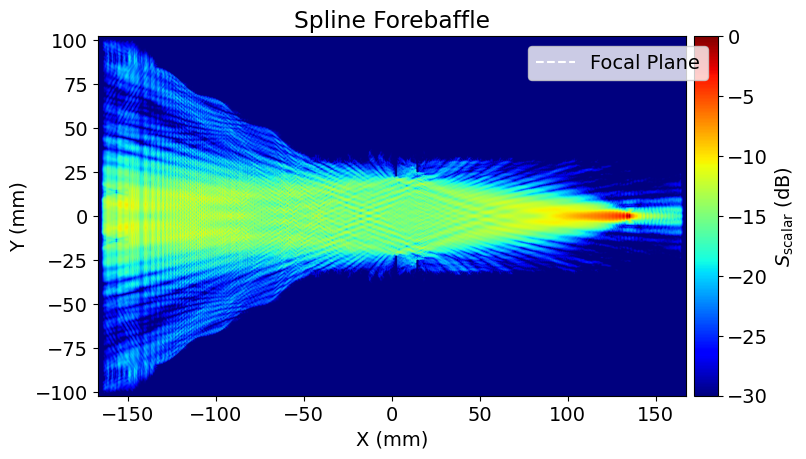

Curved Forebaffle plot saved to: ./../processed_data/simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1/0.5003461427972281GHz/s_scalar_curved_forebaffle.png


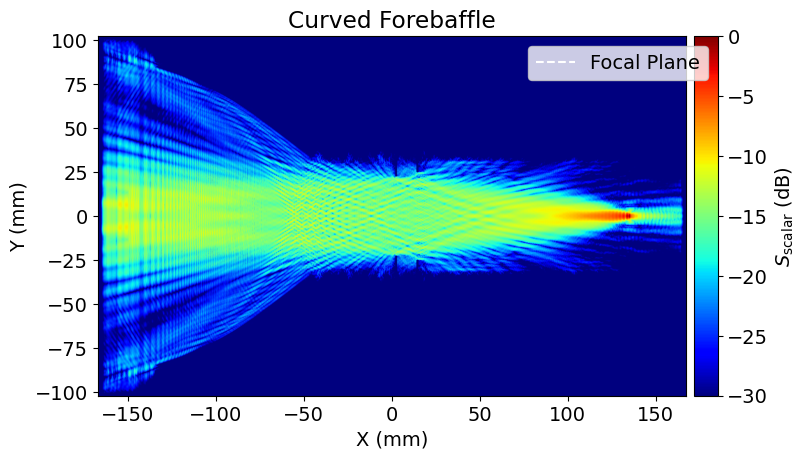

Linear Forebaffle plot saved to: ./../processed_data/simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2/0.5003461427972281GHz/s_scalar_linear_forebaffle.png


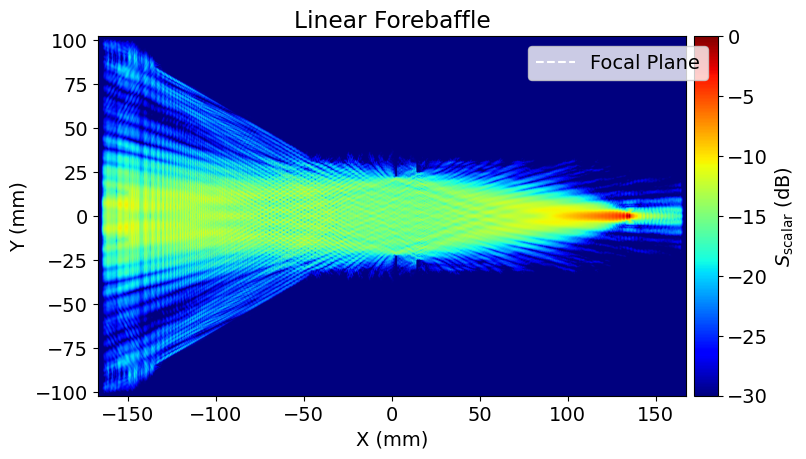

$\mathbf{S}$ Vector Field - Spline Forebaffle plot saved to: ./../processed_data/simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0/0.5003461427972281GHz/s_vector_field_spline_forebaffle.png


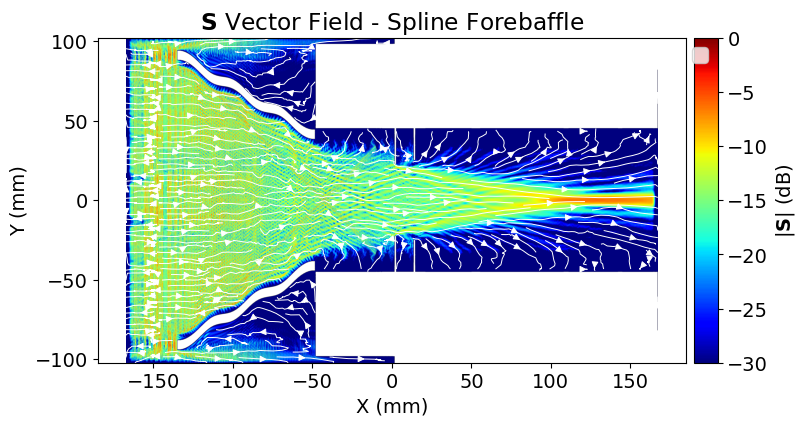

$\mathbf{S}$ Vector Field - Curved Forebaffle plot saved to: ./../processed_data/simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1/0.5003461427972281GHz/s_vector_field_curved_forebaffle.png


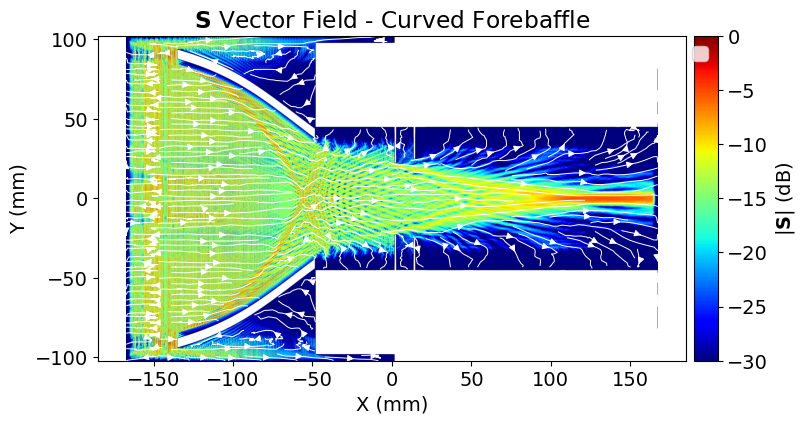

$\mathbf{S}$ Vector Field - Linear Forebaffle plot saved to: ./../processed_data/simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2/0.5003461427972281GHz/s_vector_field_linear_forebaffle.png


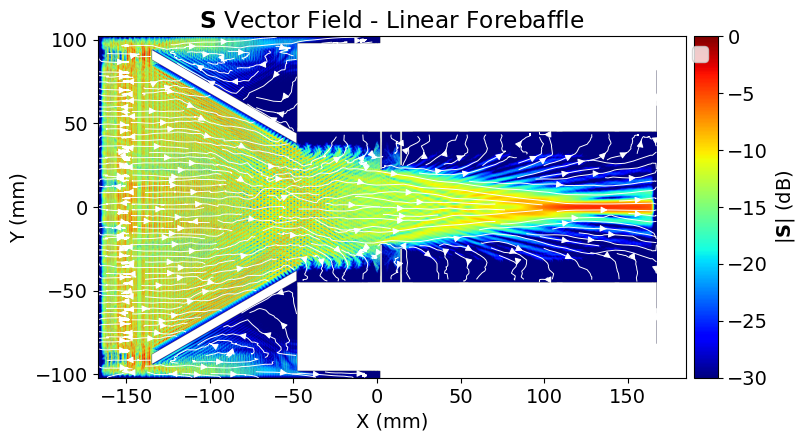

In [17]:
def s_scalar(sx_tfwd, sy_tfwd, sx_trv, sy_trv):
    """
    Compute the scalar value of the Poynting vector.

    Parameters
    ----------
    sx_tfwd : np.ndarray
        x-component of the Poynting vector from TFWD simulation.
    sy_tfwd : np.ndarray
        y-component of the Poynting vector from TFWD simulation.
    sx_trv : np.ndarray
        x-component of the Poynting vector from TRV simulation.
    sy_trv : np.ndarray
        y-component of the Poynting vector from TRV simulation.

    Returns
    -------
    Scalar product of the Poynting vectors from TFWD and TRV simulations.
    """
    # sx_tfwd = np.abs(sx_tfwd)
    # sy_tfwd = np.abs(sy_tfwd)
    # sx_trv = np.abs(sx_trv)
    # sy_trv = np.abs(sy_trv)
    # s_scalar = np.sqrt((np.dot(sx_tfwd, -sx_trv.T)) + (np.dot(sy_tfwd, -sy_trv.T)))
    s_scalar = np.sqrt(np.abs((sx_tfwd * -1* sx_trv)+ (sy_tfwd * -1* sy_trv)))
    s_scalar_db = 10 * np.log10(s_scalar / np.max(s_scalar) + 1e-20)
    return s_scalar_db

def plot_s_scalar(simname, s_array, title, filename, x_coords, y_coords, freq,
                  vmin= None, vmax=None, cmap = 'jet', savepath = os.path.join('./../processed_data/'),
                  show_plot = True, save_plot = True, mark_x = None, mark_x_label = None):
    """
    Plot the scalar value of the Poynting vector.
    """
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    # Set the label and title font sizes
    plt.rcParams.update({'font.size': 14})

    fig, ax = plt.subplots(figsize=(8, 6))

    im = ax.imshow(
        s_array.T,
        extent=(x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]),
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$S_{\mathrm{scalar}}$ (dB)')
    ax.set_title(title)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')

    if mark_x is not None:
            plt.axvline(x=mark_x, color='white', linestyle='--', label=mark_x_label)
    plt.legend(loc='upper right')
    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plot:
        plt.show()
    

def plot_s_vector_field(simname, sx, sy, title, filename, x_coords, y_coords, freq,
                        vmin=None, vmax=None, cmap='jet', savepath=os.path.join('./../processed_data/'),
                        show_plot=True, save_plot=True, mark_x=None, mark_x_label=None):
    """
    Plot the vector field of the Poynting vector over the poynting amplitude map.
    """
    # Extract the phase and amplitude map from the poynting vector components
    angle_map = np.rad2deg(np.arctan2(np.real(sy), np.real(sx)))
    S_amplitude = np.abs(np.real(sy)+ 1j*np.real(sx))
    
    from scipy.ndimage import gaussian_filter
    # Apply light Gaussian smoothing to the amplitude data
    S_amplitude_smooth = gaussian_filter(S_amplitude, sigma=2.5)
    import matplotlib.pyplot as plt
    from mpl_toolkits.axes_grid1 import make_axes_locatable
    
    # Set the label and title font sizes
    plt.rcParams.update({'font.size': 14})

    fig, ax = plt.subplots(figsize=(8, 6))
    
    im = ax.imshow(
        10 * np.log10(S_amplitude / np.max(S_amplitude)).T,
        extent=(x_coords[0], x_coords[-1], y_coords[0], y_coords[-1]),
        origin='lower',
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.08)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'$|\mathbf{S}|$ (dB)')
    ax.set_title(title)
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title(title)
    
    X, Y = np.meshgrid(x_coords, y_coords)
    # sx_smooth = gaussian_filter(np.real(sx), sigma=2.5)
    # sy_smooth = gaussian_filter(np.real(sy), sigma=2.5)
    ax.streamplot(X, Y, np.real(sx).T, np.real(sy).T, color='white', density=2, linewidth=0.7, 
                  arrowsize=1, broken_streamlines= True)
    
    
    if mark_x is not None:
            plt.axvline(x=mark_x, color='white', linestyle='--', label=mark_x_label)
    plt.legend(loc='upper right')
    
    if savepath:
        # Create directory with simname and frequency subdirectories
        save_dir = os.path.join(savepath, simname, f'{freq}GHz')
        os.makedirs(save_dir, exist_ok=True)
        plt.savefig(os.path.join(save_dir, filename), dpi=300)
        plt.savefig(os.path.join(save_dir, filename).replace('.png', '.svg'), dpi=300) 
        print(f"{title} plot saved to: {os.path.join(save_dir, filename)}")
    if show_plot:
        plt.show()


# For Spline forebaffle configuration (config_0)
spline_trv_results = trv_results[0]
spline_tfwd_results = tfwd_results[0]
spline_s_scalar = s_scalar(spline_tfwd_results["sx"], spline_tfwd_results["sy"], spline_trv_results["sx"], spline_trv_results["sy"])

# For Curved forebaffle configuration (config_1)
curved_trv_results = trv_results[1]
curved_tfwd_results = tfwd_results[1]
curved_s_scalar = s_scalar(curved_tfwd_results["sx"], curved_tfwd_results["sy"], curved_trv_results["sx"], curved_trv_results["sy"])

# For Linear forebaffle configuration (config_2)
linear_trv_results = trv_results[2]
linear_tfwd_results = tfwd_results[2]
linear_s_scalar = s_scalar(linear_tfwd_results["sx"], linear_tfwd_results["sy"], linear_trv_results["sx"], linear_trv_results["sy"])

# Plot and save the s_scalar results for configuration 0
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0", 
              s_array = spline_s_scalar, 
              title = "Spline Forebaffle", 
              filename = "s_scalar_spline_forebaffle.png", 
              x_coords = spline_trv_results["xyzw"]["x_coords"], 
              y_coords = spline_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True, 
              mark_x= 135,
              mark_x_label= "Focal Plane")

# Plot and save the s_scalar results for configuration 1
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1", 
              s_array = curved_s_scalar, 
              title = "Curved Forebaffle", 
              filename = "s_scalar_curved_forebaffle.png", 
              x_coords = curved_trv_results["xyzw"]["x_coords"], 
              y_coords = curved_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

# Plot and save the s_scalar results for configuration 2
plot_s_scalar(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2", 
              s_array = linear_s_scalar, 
              title = "Linear Forebaffle", 
              filename = "s_scalar_linear_forebaffle.png", 
              x_coords = linear_trv_results["xyzw"]["x_coords"], 
              y_coords = linear_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True,
              mark_x= 135,
              mark_x_label= "Focal Plane")

#========== plot the s_vector_fields ==========#
# COnfig 0  
plot_s_vector_field(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_0", 
              sx = spline_tfwd_results["sx"], 
              sy = spline_tfwd_results["sy"], 
              title = r"$\mathbf{S}$ Vector Field - Spline Forebaffle", 
              filename = "s_vector_field_spline_forebaffle.png", 
              x_coords = spline_trv_results["xyzw"]["x_coords"], 
              y_coords = spline_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True)

# COnfig 1
plot_s_vector_field(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_1", 
              sx = curved_tfwd_results["sx"], 
              sy = curved_tfwd_results["sy"], 
              title = r"$\mathbf{S}$ Vector Field - Curved Forebaffle", 
              filename = "s_vector_field_curved_forebaffle.png", 
              x_coords = curved_trv_results["xyzw"]["x_coords"], 
              y_coords = curved_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True)

# COnfig 2
plot_s_vector_field(simname = "simple_single_lens_AddedComplexities_TFWDxTRV_b_config_2", 
              sx = linear_tfwd_results["sx"], 
              sy = linear_tfwd_results["sy"], 
              title = r"$\mathbf{S}$ Vector Field - Linear Forebaffle", 
              filename = "s_vector_field_linear_forebaffle.png", 
              x_coords = linear_trv_results["xyzw"]["x_coords"], 
              y_coords = linear_trv_results["xyzw"]["y_coords"], 
              freq = freq,
              vmin=-30, vmax=0, 
              cmap='jet', savepath = os.path.join('./../processed_data/'), 
              show_plot = True, save_plot = True)
